c:\Users\admin\miniconda3\envs\tf\lib\site-packages\osgeo\gdal.py:287: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


AttributeError: 'AxesSubplot' object has no attribute 'view_init'

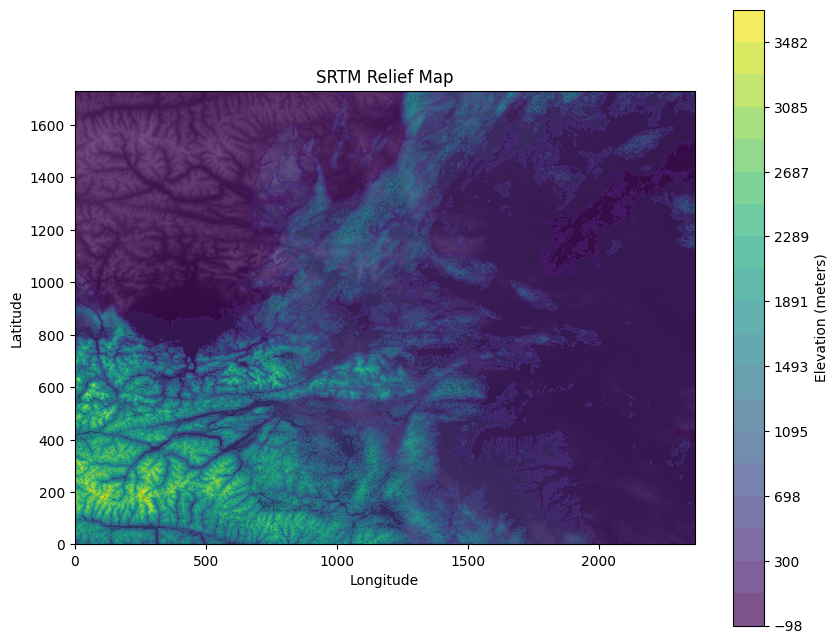

In [2]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np

# Load the SRTM data
dataset = gdal.Open(r'../data/shading/srtm_slo_250.tif')
band1 = dataset.GetRasterBand(1)
elevation = band1.ReadAsArray()

# Create a Matplotlib figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Display the SRTM relief data as a background
ax.imshow(elevation, cmap='gray', extent=[0, elevation.shape[1], 0, elevation.shape[0]], origin='upper')

# Customize the appearance of the SRTM background
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('SRTM Relief Map')

# Define contour levels and colormap for the overlay
contour_levels = np.linspace(elevation.min(), elevation.max(), 20)
contour_colormap = plt.get_cmap('viridis')

# Create color contours on top of the SRTM background
contour = ax.contourf(elevation, levels=contour_levels, cmap=contour_colormap, alpha=0.7)

# Add a colorbar for the contour levels
cbar = plt.colorbar(contour, ax=ax, label='Elevation (meters)')

# Make it 3D-like by adjusting the perspective
ax.view_init(elev=45, azim=45)  # Adjust elevation and azimuth for 3D effect

# Save or display the resulting 3D-like map
plt.savefig('3DReliefMap.png')
plt.show()


1
